<a href="https://colab.research.google.com/github/WilfredoPS/MLInvestigacionDecisionTreeGroup/blob/main/CART_Decision_Tree_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Algoritmo CART — Árbol de Decisión
**Tarea 1 – Investigación en Grupo | Módulo: Algoritmos de Machine Learning**

---

## 1. Descripción del Algoritmo

**CART** (Classification and Regression Trees) es un algoritmo de aprendizaje supervisado para la construcción de árboles de decisión, desarrollado por **Leo Breiman, Jerome Friedman, Richard Olshen y Charles Stone** en 1984. Es uno de los algoritmos más influyentes en el campo de Machine Learning y sirve como base para métodos de ensamble como **Random Forest** y **Gradient Boosting**.

El algoritmo construye árboles de decisión **estrictamente binarios** (cada nodo se divide en exactamente dos ramas), utilizando el **Índice de Gini** para clasificación o el **Error Cuadrático Medio (MSE)** para regresión, seleccionando en cada nodo la variable y el umbral de corte que mejor separa los datos.

A diferencia de ID3 y C4.5, CART puede:
- Construir tanto **árboles de clasificación** como de **regresión**
- Realizar **únicamente divisiones binarias** (umbral numérico o bipartición categórica)
- Manejar **valores faltantes** mediante variables sustitutas (surrogate splits)
- Aplicar **poda por costo-complejidad** (Cost-Complexity Pruning / Weakest Link Pruning)
- Proporcionar métricas de **importancia de características** basadas en reducción de impureza

## 2. Publicación que Propuso el Algoritmo (BibTeX y Referencias)

### BibTeX Original — CART (Breiman et al., 1984)
```bibtex
@book{breiman1984classification,
  title     = {Classification and Regression Trees},
  author    = {Breiman, Leo and Friedman, Jerome H. and Olshen, Richard A. and Stone, Charles J.},
  year      = {1984},
  publisher = {Wadsworth and Brooks/Cole},
  address   = {Monterey, California},
  isbn      = {0-534-98053-8}
}
```

### BibTeX — Poda por Costo-Complejidad (Breiman, 1996)
```bibtex
@article{breiman1996technical,
  title   = {Technical Note: Some Properties of Splitting Criteria},
  author  = {Breiman, Leo},
  journal = {Machine Learning},
  volume  = {24},
  number  = {1},
  pages   = {41--47},
  year    = {1996},
  publisher = {Springer}
}
```

### Referencias APA
- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth and Brooks/Cole.
- Breiman, L. (1996). Technical note: Some properties of splitting criteria. *Machine Learning, 24*(1), 41–47.

## 3. Tipo de Modelo

| Dimensión | Clasificación |
|---|---|
| **Método de Aprendizaje** | Aprendizaje Supervisado — Clasificación **y** Regresión |
| **Por Parámetros** | No Paramétrico — no asume ninguna distribución estadística de los datos |
| **Datos de Aprendizaje** | Offline / Batch — se entrena con todo el conjunto de datos a la vez |
| **Resultado del Entrenamiento** | Basado en Modelo — genera un árbol de decisión binario (estructura matemática/lógica) |

## 4. Algoritmo de Entrenamiento

CART utiliza criterios distintos según la tarea:

### Fórmulas clave — Clasificación:

**Índice de Gini (impureza de un nodo):**
$$Gini(t) = 1 - \sum_{i=1}^{c} p_i^2$$

donde $p_i$ es la proporción de la clase $i$ en el nodo $t$.

**Reducción de Gini al dividir el nodo $t$ en $t_L$ y $t_R$:**
$$\Delta Gini(t, A) = Gini(t) - \frac{|t_L|}{|t|}\,Gini(t_L) - \frac{|t_R|}{|t|}\,Gini(t_R)$$

### Fórmulas clave — Regresión:

**Error Cuadrático Medio (MSE) en un nodo:**
$$MSE(t) = \frac{1}{|t|} \sum_{i \in t} (y_i - \bar{y}_t)^2$$

**Poda por Costo-Complejidad:**
$$R_\alpha(T) = R(T) + \alpha \cdot |\tilde{T}|$$

donde $R(T)$ es el error del árbol, $|\tilde{T}|$ el número de hojas y $\alpha$ el parámetro de complejidad.

### Proceso:
1. Para cada atributo y cada umbral posible, calcular la **reducción de Gini** (o MSE)
2. Seleccionar la combinación atributo–umbral con **mayor reducción** como punto de corte
3. Dividir el nodo en **exactamente dos ramas** (binario)
4. Repetir recursivamente hasta alcanzar nodos puros o criterio de parada
5. Aplicar **poda por costo-complejidad** (ccp_alpha) para reducir el sobreajuste

## 5. Tipos de Entrada

- **Atributos categóricos** (ej: color, tipo, categoría) — CART realiza bipartición de categorías
- **Atributos numéricos/continuos** (ej: edad, temperatura, precio) — selecciona umbrales de corte óptimos
- **Valores faltantes (NaN)** — manejados mediante *surrogate splits* (variables sustitutas)
- **Variable objetivo:** categórica (clasificación con Gini) o numérica (regresión con MSE/MAE)
- **Formato de entrada:** tabla/dataset con filas=muestras, columnas=características

## 6. Casos de Uso

| Área | Aplicación |
|---|---|
| 🏥 Medicina | Diagnóstico de enfermedades y predicción de resultados clínicos |
| 💳 Finanzas | Detección de fraude, scoring crediticio y predicción de precios |
| 📧 Marketing | Segmentación de clientes y predicción de churn |
| 🏠 Inmobiliario | Predicción del precio de inmuebles (regresión) |
| 🌿 Biología | Clasificación de especies y análisis genómico |
| 🤖 Ensamble | Base de Random Forest, Gradient Boosting y XGBoost |

## 7. Supuestos y Restricciones

### Supuestos:
- Los datos de entrenamiento son representativos de la distribución real
- Las relaciones entre variables pueden representarse mediante divisiones jerárquicas binarias
- La impureza (Gini o MSE) es una medida válida de la calidad de cada división

### Restricciones:
- Genera **únicamente árboles binarios** — puede ser más profundo que algoritmos multivía
- Propenso al **sobreajuste** sin poda (ccp_alpha) o límites de profundidad
- **Inestabilidad**: pequeñas variaciones en los datos pueden cambiar la estructura del árbol
- No captura bien **relaciones lineales simples** (la regresión lineal sería más eficiente)
- Puede tener **sesgo hacia variables continuas** con muchos umbrales posibles
- La complejidad computacional crece con el número de características y muestras

## 8. Source Code — Implementación en Python

Usaremos `scikit-learn` que implementa CART de manera nativa mediante `DecisionTreeClassifier` (clasificación) y `DecisionTreeRegressor` (regresión), con soporte completo para poda por costo-complejidad (`ccp_alpha`).

In [ ]:
# Instalación (solo necesario en Colab si no está disponible)
# !pip install scikit-learn matplotlib pandas seaborn

In [ ]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [ ]:
# ============================================================
# PASO 2: Cargar dataset (Iris — clásico para clasificación)
# ============================================================
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

print('Shape del dataset:', X.shape)
print('Clases:', iris.target_names)
X.head()

Shape del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# ============================================================
# PASO 3: División Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')

Train: 105 muestras
Test:  45 muestras


In [ ]:
# ============================================================
# PASO 4: Entrenar el modelo CART
# criterion='gini'  → Índice de Gini (criterio original de CART)
# max_depth         → Profundidad máxima para controlar sobreajuste
# min_samples_split → Mínimo de muestras para dividir un nodo
# ccp_alpha         → Parámetro de poda por costo-complejidad (0 = sin poda)
# ============================================================
modelo_cart = DecisionTreeClassifier(
    criterion='gini',       # Criterio original de CART
    max_depth=5,            # Limitar profundidad para evitar sobreajuste
    min_samples_split=5,    # Mínimo de muestras para dividir
    min_samples_leaf=2,     # Mínimo de muestras en hoja
    ccp_alpha=0.0,          # Sin poda adicional (ver Paso 9 para tuning)
    random_state=42
)

modelo_cart.fit(X_train, y_train)
print('Modelo CART entrenado con éxito')
print(f'Profundidad del árbol: {modelo_cart.get_depth()}')
print(f'Número de hojas:       {modelo_cart.get_n_leaves()}')

Modelo CART entrenado con éxito
Profundidad del árbol: 4
Número de hojas:       6


In [ ]:
# ============================================================
# PASO 5: Evaluación del modelo
# ============================================================
y_pred = modelo_cart.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 88.89 %

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



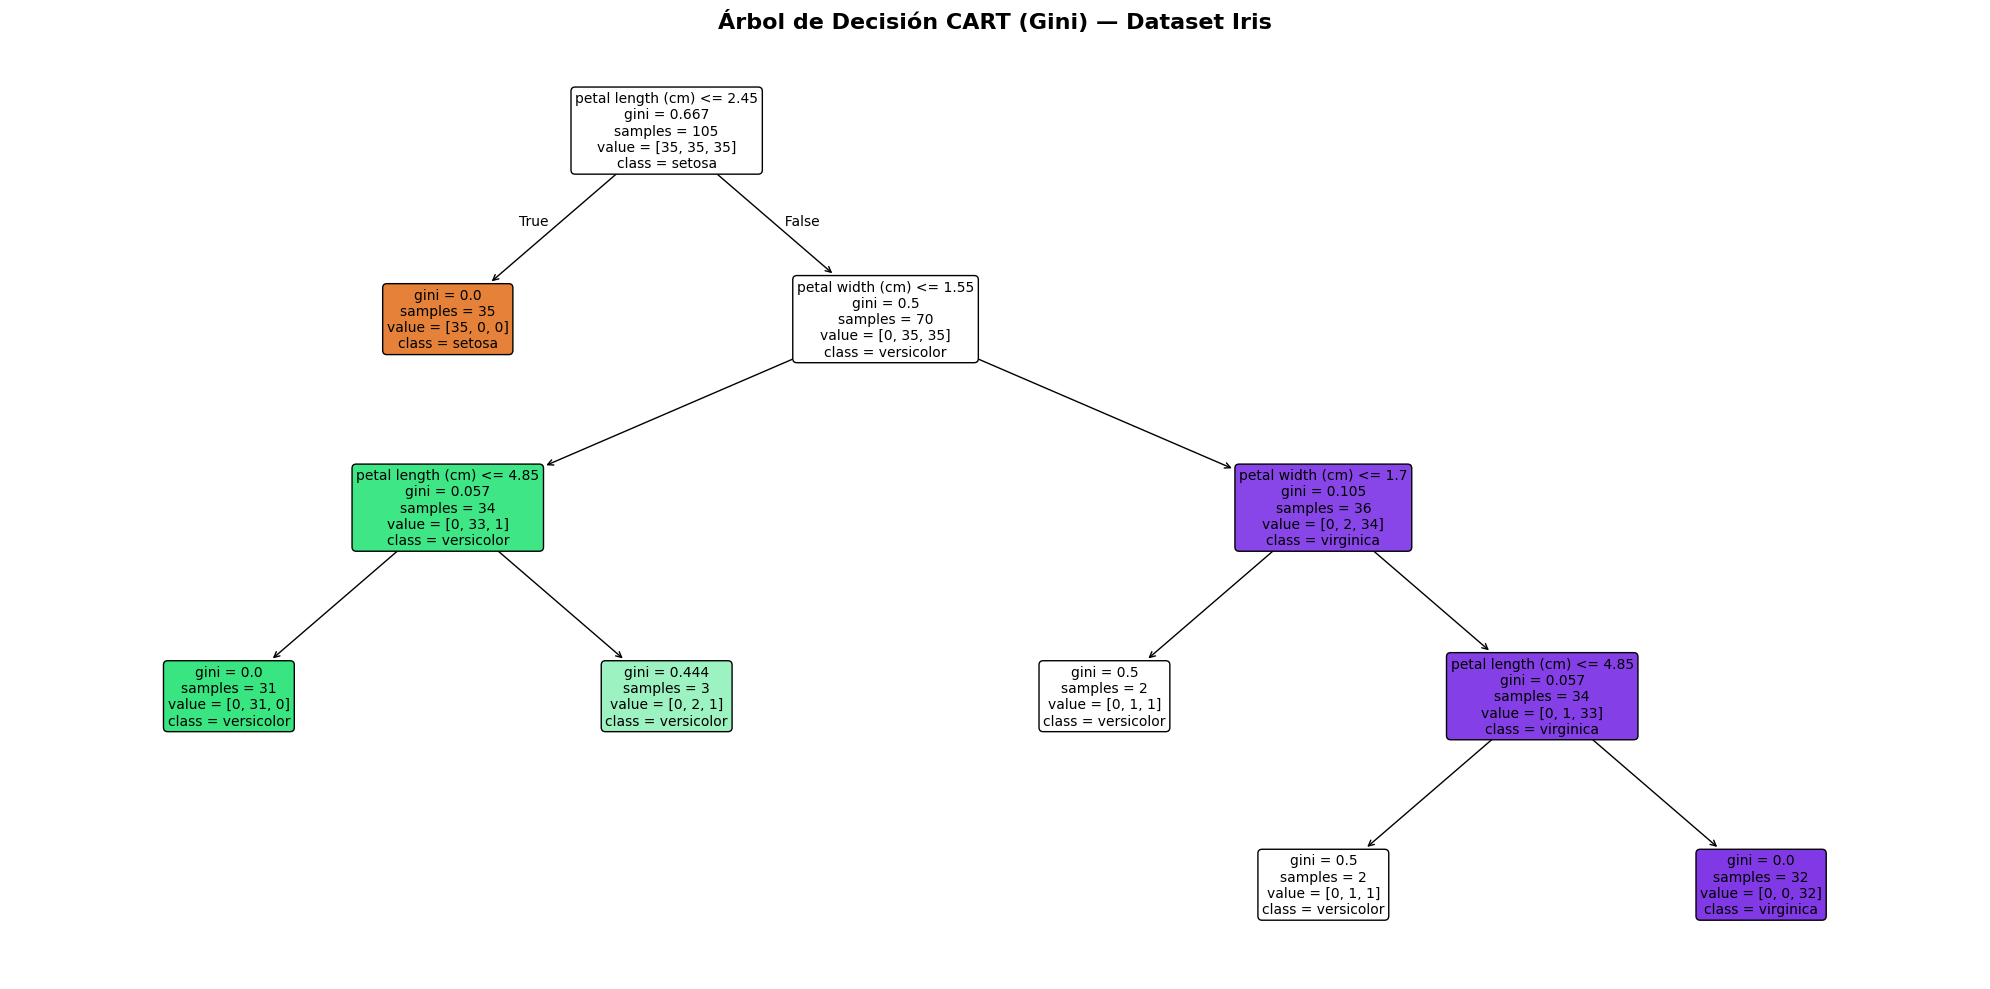

In [ ]:
# ============================================================
# PASO 6: Visualizar el Árbol de Decisión CART
# ============================================================
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_cart,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True    # Muestra el Índice de Gini en cada nodo
)
plt.title('Árbol de Decisión CART (Gini) — Dataset Iris', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

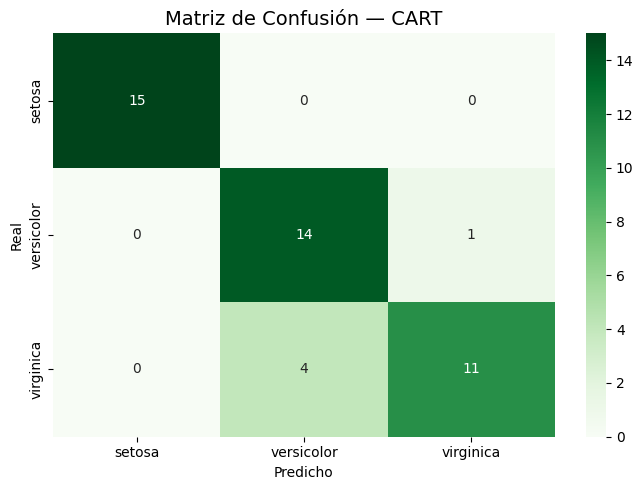

In [ ]:
# ============================================================
# PASO 7: Matriz de Confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión — CART', fontsize=14)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PASO 8: Ver las reglas IF-THEN generadas por el árbol
# ============================================================
reglas = export_text(modelo_cart, feature_names=list(iris.feature_names))
print('Reglas IF-THEN del árbol CART:')
print(reglas)

Reglas IF-THEN del árbol CART:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 1
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



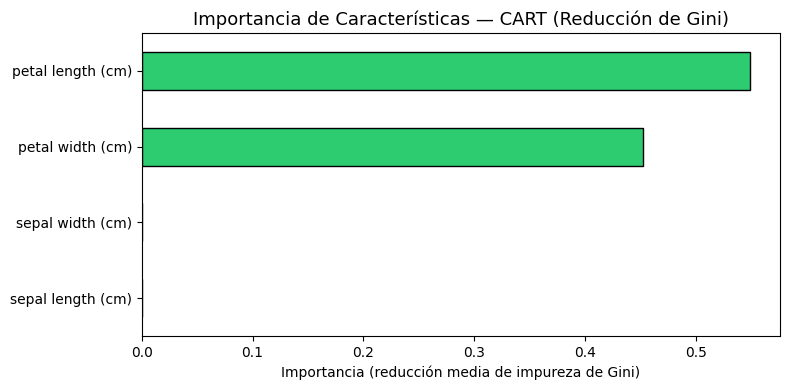

Importancias:
  petal length (cm)                   0.5482
  petal width (cm)                    0.4518
  sepal width (cm)                    0.0000
  sepal length (cm)                   0.0000


In [ ]:
# ============================================================
# PASO 9: Importancia de Características
# ============================================================
importancias = pd.Series(
    modelo_cart.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importancias.plot(kind='barh', color='#2ECC71', edgecolor='black')
plt.title('Importancia de Características — CART (Reducción de Gini)', fontsize=13)
plt.xlabel('Importancia (reducción media de impureza de Gini)')
plt.tight_layout()
plt.show()

print('Importancias:')
for feat, imp in importancias.sort_values(ascending=False).items():
    print(f'  {feat:<35} {imp:.4f}')

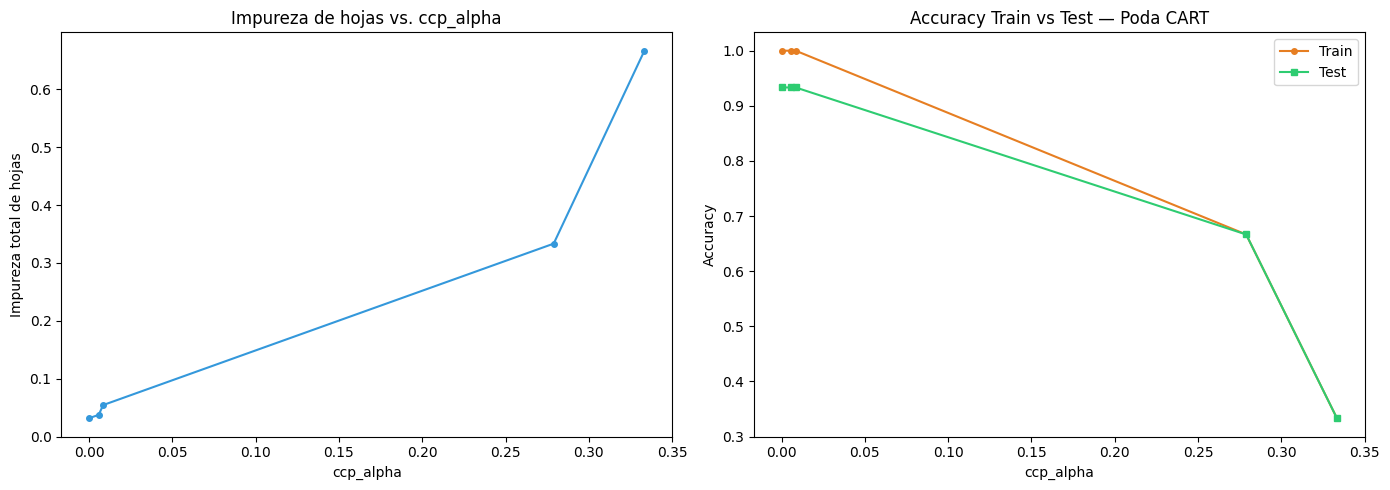

Mejor ccp_alpha: 0.00000  →  Test Accuracy: 93.33%


In [ ]:
# ============================================================
# PASO 9b: Poda por Costo-Complejidad (ccp_alpha tuning)
# Característica distintiva de CART — controla el sobreajuste
# ============================================================
path = modelo_cart.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities  = path.impurities

# Evaluar accuracy para cada valor de ccp_alpha
acc_train_list, acc_test_list = [], []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='gini', ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, clf.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, clf.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Impureza total vs alpha
axes[0].plot(ccp_alphas, impurities, marker='o', color='#3498DB', markersize=4)
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Impureza total de hojas')
axes[0].set_title('Impureza de hojas vs. ccp_alpha')

# Gráfico 2: Accuracy vs alpha
axes[1].plot(ccp_alphas, acc_train_list, marker='o', label='Train',
             color='#E67E22', markersize=4)
axes[1].plot(ccp_alphas, acc_test_list, marker='s', label='Test',
             color='#2ECC71', markersize=4)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Train vs Test — Poda CART')
axes[1].legend()

plt.tight_layout()
plt.show()

# Mejor alpha según test accuracy
best_alpha = ccp_alphas[np.argmax(acc_test_list)]
print(f'Mejor ccp_alpha: {best_alpha:.5f}  →  Test Accuracy: {max(acc_test_list)*100:.2f}%')

In [ ]:
# ============================================================
# PASO 10: Predicción con nuevos datos
# ============================================================
# Ejemplo: nueva flor con medidas [sépalo largo, sépalo ancho, pétalo largo, pétalo ancho]
nueva_muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Probablemente setosa

prediccion   = modelo_cart.predict(nueva_muestra)
probabilidad = modelo_cart.predict_proba(nueva_muestra)

print(f'Predicción: {iris.target_names[prediccion[0]]}')
print()
print('Probabilidades por clase:')
for nombre, prob in zip(iris.target_names, probabilidad[0]):
    print(f'   {nombre}: {prob:.2%}')

Predicción: setosa

Probabilidades por clase:
   setosa: 100.00%
   versicolor: 0.00%
   virginica: 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 9. Comparación CART Clasificación vs CART Regresión

| Característica | CART Clasificación | CART Regresión |
|---|---|---|
| **Criterio de impureza** | Índice de Gini (default) o Entropía | MSE / MAE / Friedman MSE |
| **Valor en nodo hoja** | Clase mayoritaria | Media de $y$ en el nodo |
| **Variable objetivo** | Categórica | Continua |
| **Métrica de evaluación** | Accuracy, F1, AUC | RMSE, MAE, R² |
| **Clase scikit-learn** | `DecisionTreeClassifier` | `DecisionTreeRegressor` |

> **CART** es el algoritmo base que scikit-learn implementa internamente para todos sus `DecisionTree*` y también para los árboles dentro de `RandomForest*` y `GradientBoosting*`.

---
# Ejemplo Práctico — CART Regresión

Una característica clave que distingue a **CART** de ID3 y C4.5 es su capacidad nativa para **árboles de regresión**. Aquí lo demostramos usando el dataset California Housing:

- Variable objetivo continua (precio mediano de casas)
- Criterio de división: **MSE** (Error Cuadrático Medio)
- El valor de cada hoja es la **media** de las muestras en ese nodo

## CART Regresión — scikit-learn con DecisionTreeRegressor

In [ ]:
# ============================================================
# CART REGRESIÓN — Dataset California Housing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar dataset
housing = fetch_california_housing()
X_h = pd.DataFrame(housing.data, columns=housing.feature_names)
y_h = pd.Series(housing.target, name='MedHouseVal')

print('Dataset California Housing')
print('Shape:', X_h.shape)
print('Variable objetivo (precio mediano):', y_h.describe().to_dict())
X_h.head()

Dataset California Housing
Shape: (20640, 8)
Variable objetivo (precio mediano): {'count': 20640.0, 'mean': 2.068558169089147, 'std': 1.1539561587441483, 'min': 0.14999, '25%': 1.196, '50%': 1.797, '75%': 2.6472499999999997, 'max': 5.00001}


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# ============================================================
# CART Regresión — Entrenamiento y Evaluación
# ============================================================
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

modelo_reg = DecisionTreeRegressor(
    criterion='squared_error',   # MSE — criterio original de CART Regresión
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

modelo_reg.fit(X_train_h, y_train_h)
y_pred_h = modelo_reg.predict(X_test_h)

rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
mae  = mean_absolute_error(y_test_h, y_pred_h)
r2   = r2_score(y_test_h, y_pred_h)

print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R²:   {r2:.4f}')
print(f'Profundidad: {modelo_reg.get_depth()} | Hojas: {modelo_reg.get_n_leaves()}')

RMSE: 0.7242
MAE:  0.5223
R²:   0.5997
Profundidad: 5 | Hojas: 32


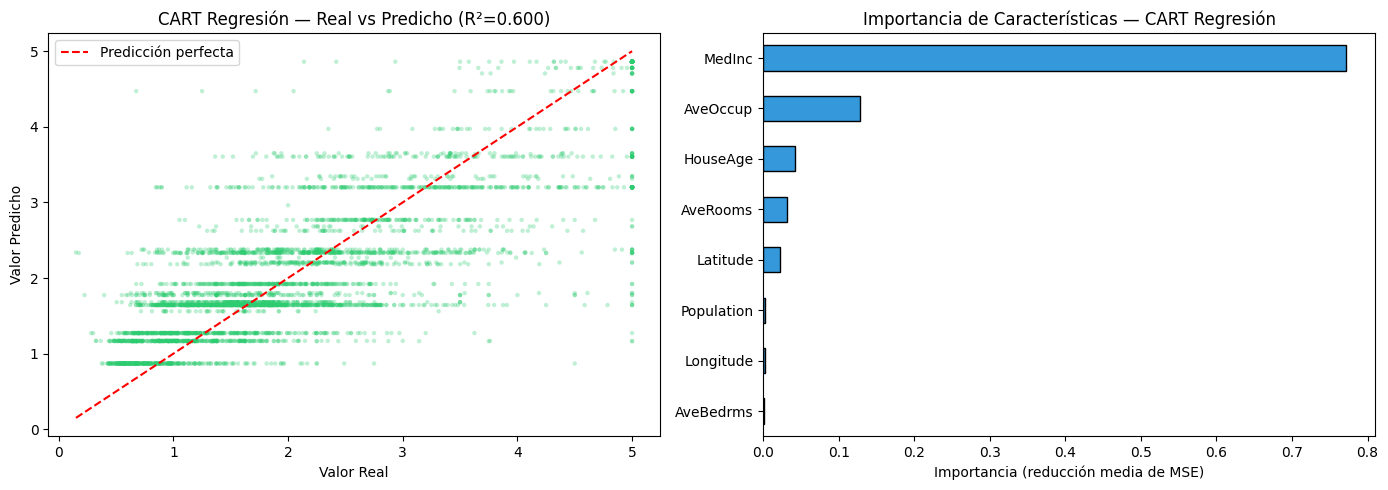

In [ ]:
# ============================================================
# CART Regresión — Visualizaciones
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Real vs Predicho
axes[0].scatter(y_test_h, y_pred_h, alpha=0.3, color='#2ECC71', edgecolors='none', s=10)
lims = [min(y_test_h.min(), y_pred_h.min()), max(y_test_h.max(), y_pred_h.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Valor Predicho')
axes[0].set_title(f'CART Regresión — Real vs Predicho (R²={r2:.3f})')
axes[0].legend()

# Gráfico 2: Importancia de características
imp_reg = pd.Series(
    modelo_reg.feature_importances_,
    index=housing.feature_names
).sort_values(ascending=True)
imp_reg.plot(kind='barh', ax=axes[1], color='#3498DB', edgecolor='black')
axes[1].set_title('Importancia de Características — CART Regresión')
axes[1].set_xlabel('Importancia (reducción media de MSE)')

plt.tight_layout()
plt.show()

  CART (Gini)               Accuracy: 88.89%
  CART Podado (ccp)         Accuracy: 93.33%
  C4.5 (Entropía)           Accuracy: 88.89%


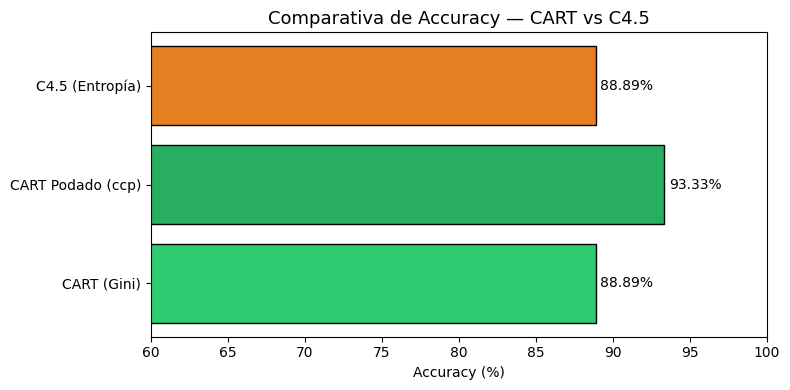

In [ ]:
# ============================================================
# COMPARATIVA: CART vs C4.5 vs CHAID — Dataset Iris
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# CART — Gini (ya entrenado)
acc_cart = accuracy_score(y_test, y_pred)

# C4.5 aproximado — Entropía
c45 = DecisionTreeClassifier(criterion='entropy', max_depth=5,
                              min_samples_split=5, random_state=42)
c45.fit(X_train, y_train)
acc_c45 = accuracy_score(y_test, c45.predict(X_test))

# CART podado — mejor ccp_alpha encontrado en Paso 9b
cart_podado = DecisionTreeClassifier(criterion='gini', ccp_alpha=best_alpha, random_state=42)
cart_podado.fit(X_train, y_train)
acc_cart_pod = accuracy_score(y_test, cart_podado.predict(X_test))

modelos    = ['CART (Gini)', 'CART Podado (ccp)', 'C4.5 (Entropía)']
accuracies = [acc_cart * 100, acc_cart_pod * 100, acc_c45 * 100]

print('=' * 50)
for m, a in zip(modelos, accuracies):
    print(f'  {m:<25} Accuracy: {a:.2f}%')
print('=' * 50)

plt.figure(figsize=(8, 4))
bars = plt.barh(modelos, accuracies,
                color=['#2ECC71', '#27AE60', '#E67E22'], edgecolor='black')
plt.xlim(60, 100)
plt.xlabel('Accuracy (%)')
plt.title('Comparativa de Accuracy — CART vs C4.5', fontsize=13)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{acc:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()